# 02. OpenStreetMap Infrastructure Processing and Visualization

This notebook demonstrates the Phase 2 OpenStreetMap (OSM) pipeline: downloading buildings, roads, and green spaces, creating a spatial grid, and visualising computed infrastructure features (such as building density).

In [7]:
import sys
from pathlib import Path
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is in path
sys.path.append(str(Path.cwd().parent))
from config import Config

## 1. Load Study Boundary and Raw Vector Layers
We load the administrative boundary GeoJSON for **Pune** (or another city) and read its raw downloaded OSM datasets.

Boundary CRS: EPSG:4326


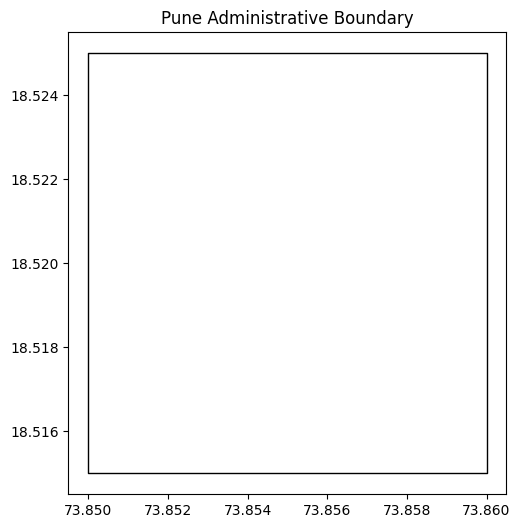

In [8]:
city = "Pune"  # Options: "Pune", "Bengaluru", "Hyderabad"
boundary_path = Config.BOUNDARIES_DIR / f"{city}.geojson"
boundary_gdf = gpd.read_file(boundary_path)
print(f"Boundary CRS: {boundary_gdf.crs}")
boundary_gdf.plot(edgecolor='black', color='none', figsize=(6, 6))
plt.title(f"{city} Administrative Boundary")
plt.show()

In [9]:
raw_dir = Config.RAW_OSM_DIR / city

try:
    buildings = gpd.read_file(raw_dir / "buildings.geojson")
    roads = gpd.read_file(raw_dir / "roads.geojson")
    green_areas = gpd.read_file(raw_dir / "green_areas.geojson")
    
    print(f"Raw Buildings Count: {len(buildings)}")
    print(f"Raw Road Segments: {len(roads)}")
    print(f"Raw Green Areas: {len(green_areas)}")
except Exception as e:
    print(f"Error loading raw files: {e}. Make sure downloader script has run successfully.")

Raw Buildings Count: 2270
Raw Road Segments: 1361
Raw Green Areas: 11


c:\Users\Sri Nidhi\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\io\file.py:576: UserWarning: Could not parse column 'reversed' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


## 2. Visualize Raw Vector Data
Let's plot raw spatial overlays to inspect vector density.

C:\Users\Sri Nidhi\AppData\Local\Temp\ipykernel_22988\1944443064.py:10: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


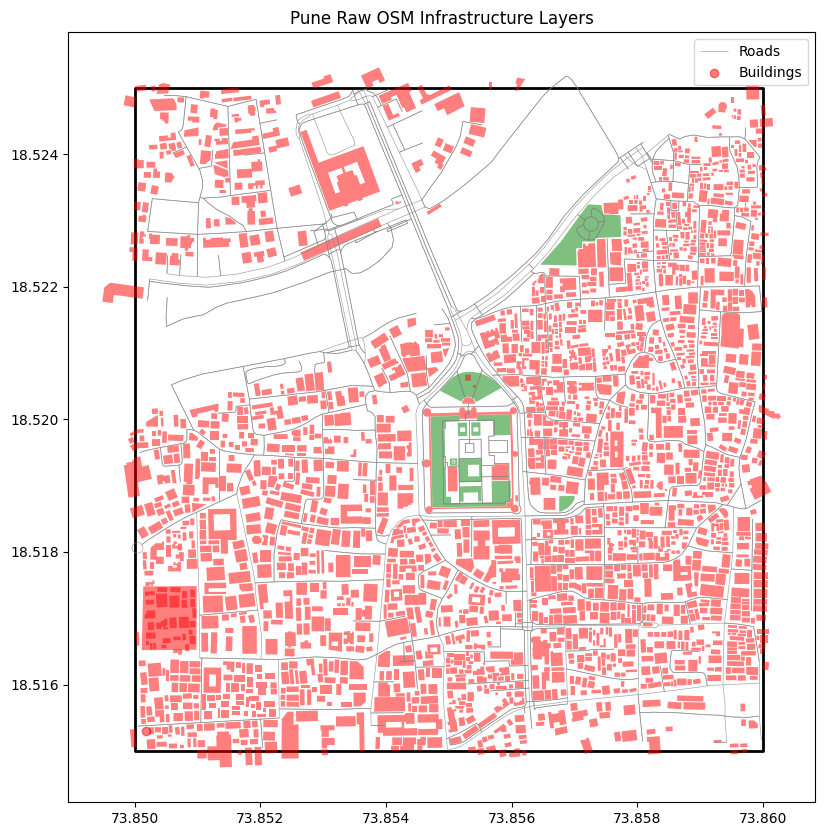

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))
boundary_gdf.plot(ax=ax, edgecolor='black', color='none', linewidth=2, label='Boundary')
if 'roads' in locals() and not roads.empty:
    roads.plot(ax=ax, color='gray', linewidth=0.5, alpha=0.7, label='Roads')
if 'green_areas' in locals() and not green_areas.empty:
    green_areas.plot(ax=ax, color='green', alpha=0.5, label='Green Areas')
if 'buildings' in locals() and not buildings.empty:
    buildings.plot(ax=ax, color='red', alpha=0.5, label='Buildings')
plt.title(f"{city} Raw OSM Infrastructure Layers")
plt.legend()
plt.show()

## 3. Visualize Spatial Grid & Engineered Feature Map
Next, we load the spatial grid and inspect the computed density and distance metrics.

Generated Grid Cells Count: 36
Grid CRS: EPSG:3857


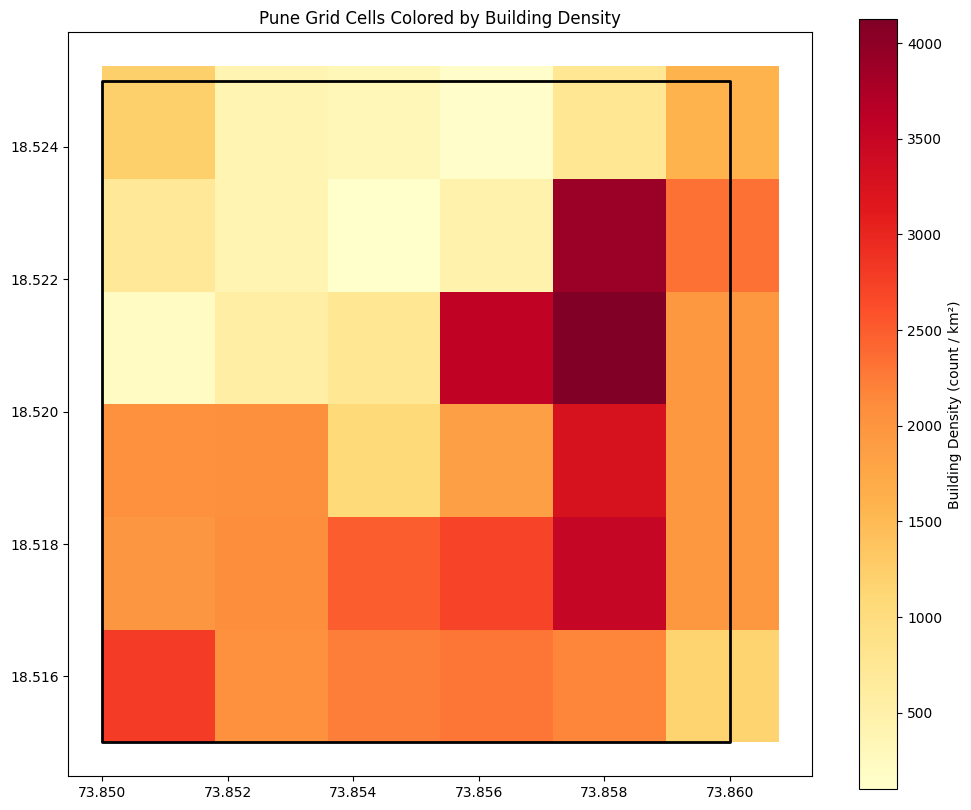

In [11]:
interim_dir = Config.INTERIM_DIR / "osm" / city
features_path = Config.FEATURES_DIR / f"osm_features_{city}.geojson"

try:
    grid = gpd.read_file(interim_dir / "grid.geojson")
    print(f"Generated Grid Cells Count: {len(grid)}")
    print(f"Grid CRS: {grid.crs}")
    
    # Visualise the grid colored by Building Density
    if features_path.exists():
        features_gdf = gpd.read_file(features_path)
        fig, ax = plt.subplots(figsize=(12, 10))
        features_gdf.plot(
            column='building_density',
            cmap='YlOrRd',
            legend=True,
            legend_kwds={'label': "Building Density (count / km²)"},
            ax=ax
        )
        boundary_gdf.to_crs(features_gdf.crs).plot(ax=ax, edgecolor='black', color='none', linewidth=2)
        plt.title(f"{city} Grid Cells Colored by Building Density")
        plt.show()
    else:
        print(f"Features file {features_path.name} not found. Run pipeline first.")
except Exception as e:
    print(f"Error plotting grid: {e}")

## 4. Verification Check and Metrics Profiling

In [12]:
csv_path = Config.FEATURES_DIR / f"osm_features_{city}.csv"
if csv_path.exists():
    df = pd.read_csv(csv_path)
    print("--- Features Table Head ---")
    print(df.head())
    print("\n--- Descriptive Statistics ---")
    print(df.describe())
else:
    print(f"CSV features not found at {csv_path.name}")

--- Features Table Head ---
   grid_id  building_count  building_density  building_area_ratio  \
0        0             112            2800.0             0.492363   
1        1              80            2000.0             0.633453   
2        2              82            2050.0             0.376849   
3        3               9             225.0             0.027542   
4        4              28             700.0             0.151664   

   road_length  road_density  road_intersection_count  intersection_density  \
0   822.456071     20.561402                        0                   0.0   
1   574.067230     14.351681                        0                   0.0   
2  1475.573482     36.889337                        0                   0.0   
3   973.275849     24.331896                        0                   0.0   
4  2322.938794     58.073470                        0                   0.0   

   distance_to_highway  green_area  green_ratio  distance_to_center  
0           